In [1]:
# imports 
import os
import numpy as np
import matplotlib.pyplot as plt

from pyrawph import L1_event
from pyrawph.sys_cfg import DATA_PATH, REPO_ROOT

In [2]:
# select product + load 
PRODUCT = str(DATA_PATH / "PHISAT-2_L1_000004663_20260216205626_20260216205629_97A6CEB3")
ev = L1_event.from_path(
    product_folder=PRODUCT,
    scene_id=0,
    product_kind="BC",
    multiband=True,
    as_float32=False,
    verbose=True,
)

[PyRawPh] Loading ΦSat-2 L1 from: C:\Users\Malo.DePastor\PyRawPh\data\PHISAT-2_L1_000004663_20260216205626_20260216205629_97A6CEB3


In [3]:
# info (PyRawS-like) 
ev.show_event_info()
ev.show_tiles_info()  

Event: scene_id=0 kind=BC
  folder: C:\Users\Malo.DePastor\PyRawPh\data\PHISAT-2_L1_000004663_20260216205626_20260216205629_97A6CEB3
  path: C:\Users\Malo.DePastor\PyRawPh\data\PHISAT-2_L1_000004663_20260216205626_20260216205629_97A6CEB3\bands\scene_0_BC_multiband.tiff
  shape: (8, 4096, 4096)   dtype: uint16
  crs: EPSG:4326
  bounds: BoundingBox(left=-141.93059130050244, bottom=59.831214491276874, right=-141.4994428456426, top=60.03740976135217)
  wavelengths_nm: [625, 490, 560, 665, 705, 740, 783, 842]
  gl_path: C:\Users\Malo.DePastor\PyRawPh\data\PHISAT-2_L1_000004663_20260216205626_20260216205629_97A6CEB3\geolocation\GL_scene_0.json
  processing_config: C:\Users\Malo.DePastor\PyRawPh\data\PHISAT-2_L1_000004663_20260216205626_20260216205629_97A6CEB3\processing_config.json
  n_tiles: 1
------------------Tile 0 ----------------------------
Name:  scene_0_BC
Sensing time:  2026-02-16 20:56:26
Creation time:  2026-02-16 20:56:29
Corners coordinates: 

	P_0 : [60.03740976135217, -141.9

In [4]:
# API overview (what methods exist) 
methods = [
    "show_event_info","show_tiles_info","get_meta","get_wavelengths","get_band",
    "show_bands","rgb","index","crop_px","make_tiles","to_tiles",
    "get_tiles_names","get_tile","plot_location","export_to_tif",
]
missing = [m for m in methods if not hasattr(ev, m)]
print("Missing:", missing)
print("OK:", [m for m in methods if hasattr(ev, m)])

Missing: []
OK: ['show_event_info', 'show_tiles_info', 'get_meta', 'get_wavelengths', 'get_band', 'show_bands', 'rgb', 'index', 'crop_px', 'make_tiles', 'to_tiles', 'get_tiles_names', 'get_tile', 'plot_location', 'export_to_tif']


In [5]:
# band resolving demo (alias / index / wavelength) 

b3 = ev.get_band(3)
red = ev.get_band("RED")
nir = ev.get_band("NIR")

print("B3 shape/dtype:", b3.shape, b3.dtype)
print("RED==B3:", np.all(red == b3))
print("NIR stats:", float(nir.min()), float(nir.max()))

# wavelength as float (nm)
nir_842 = ev.get_band(842.0)
print("842.0nm == NIR:", np.all(nir_842 == nir))

B3 shape/dtype: (4096, 4096) uint16
RED==B3: True
NIR stats: 1.0 271.0
842.0nm == NIR: True


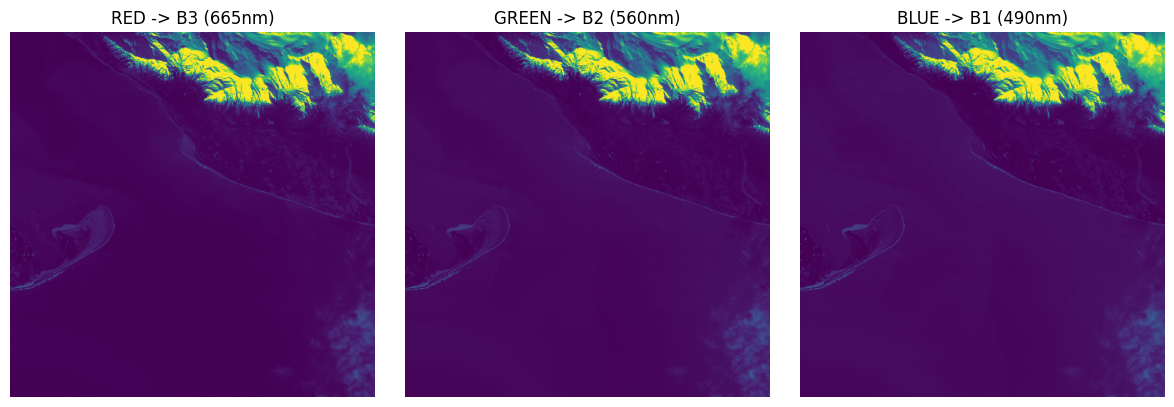

In [6]:
# show_bands (PyRawS-like) 
ev.show_bands(bands=["RED","GREEN","BLUE"], max_size=700, downsampling=True)

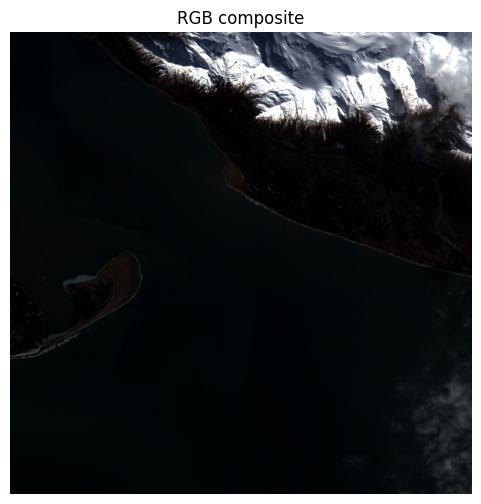

In [7]:
# RGB composite (true composite, not 3 separate plots) 

rgb = ev.rgb(("RED","GREEN","BLUE"))
plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.axis("off")
plt.title("RGB composite")
plt.show()

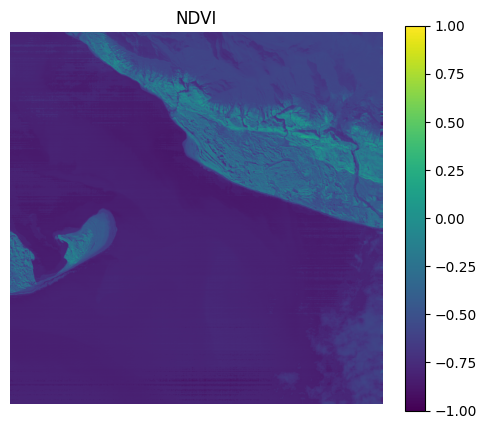

NDVI min/max: -0.9295393228530884 0.31147539615631104


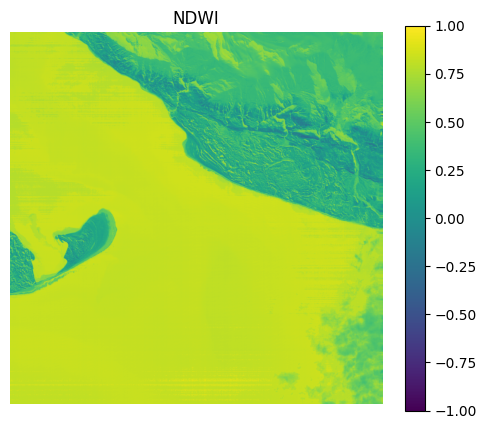

NDWI min/max: -0.38181817531585693 0.923076868057251


In [8]:
# indices 


ndvi = ev.index("NDVI").astype(np.float32)
plt.figure(figsize=(6,5))
plt.imshow(ndvi, vmin=-1, vmax=1)
plt.axis("off")
plt.title("NDVI")
plt.colorbar()
plt.show()
print("NDVI min/max:", float(np.nanmin(ndvi)), float(np.nanmax(ndvi)))

# NDWI (GREEN vs NIR)
ndwi = ev.index("NDWI").astype(np.float32)
plt.figure(figsize=(6,5))
plt.imshow(ndwi, vmin=-1, vmax=1)
plt.axis("off")
plt.title("NDWI")
plt.colorbar()
plt.show()
print("NDWI min/max:", float(np.nanmin(ndwi)), float(np.nanmax(ndwi)))

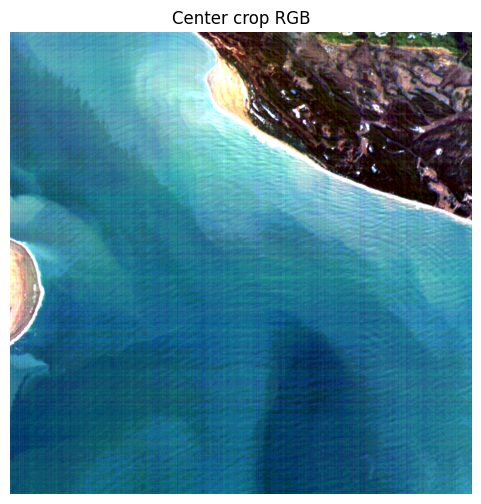

crop shape: (8, 2048, 2048) crop bounds: BoundingBox(left=-141.7767750335016, bottom=59.8827633087957, right=-141.65325911264347, top=59.985860943833345)


In [ ]:
# crop + view 

arr = ev.as_numpy()
H, W = arr.shape[1:]
crop_arr, crop_meta = ev.crop_px(H//4, 3*H//4, W//4, 3*W//4)

rgb_crop = ev.rgb(("RED","GREEN","BLUE"), arr=crop_arr)

plt.figure(figsize=(6,6))
plt.imshow(rgb_crop)
plt.axis("off")
plt.title("Center crop RGB")
plt.show()

print("crop shape:", crop_arr.shape, "crop bounds:", crop_meta.get("bounds"))

In [ ]:
# tiles (make + pick center tile) 

ev.make_tiles(tile_size=512, overlap=0, drop_last=False)
print("n_tiles:", ev.n_tiles)

# pick the tile whose (x0,y0) is closest to image center (robust)
H, W = ev.as_numpy().shape[1:]
target_x, target_y = W//2, H//2

names = ev.get_tiles_names()
def parse_xy(name: str):
    # expects "tile_y{y0}_x{x0}_s{tile_size}_o{overlap}"
    parts = name.split("_")
    y0 = int(parts[1][1:])  # "y2048" -> 2048
    x0 = int(parts[2][1:])  # "x2048" -> 2048
    return x0, y0

best = min(names, key=lambda n: (parse_xy(n)[0]-target_x)**2 + (parse_xy(n)[1]-target_y)**2)
i_best = names.index(best)
t = ev.get_tile(i_best)

print("center-ish tile:", t.tile_name, "shape:", t.arr.shape)

plt.figure(figsize=(4,4))
plt.imshow(ev.rgb(("RED","GREEN","BLUE"), arr=t.arr))
plt.axis("off")
plt.title(t.tile_name)
plt.show()

In [ ]:
# plot location 

ev.plot_location(mode="footprint", world=True, title="Footprint")
plt.show()

ev.plot_location(mode="bounds", world=True, title="Bounds (axis-aligned)")
plt.show()

# overlay a few tiles on footprint plot (indices 0, 1, 2 for example)
ev.plot_location(mode="footprint", world=True, tiles_idx=[0,1,2], title="Footprint + tiles")
plt.show()

In [ ]:
# exports + verify 
from pathlib import Path
import rasterio

OUT = Path(os.getcwd()) / "demo_outputs"
OUT.mkdir(exist_ok=True)

# export tile 0
t0 = ev.get_tile(0)
TILE0_TIF = str(OUT / "tile0_BC.tif")
ev.export_to_tif(TILE0_TIF, arr=t0.arr, meta=t0.meta)
print("exported:", TILE0_TIF)

# export center crop
arr = ev.as_numpy()
H, W = arr.shape[1:]
crop_arr, crop_meta = ev.crop_px(H//4, 3*H//4, W//4, 3*W//4)
CROP_TIF = str(OUT / "center_crop_BC.tif")
ev.export_to_tif(CROP_TIF, arr=crop_arr, meta=crop_meta)
print("exported:", CROP_TIF)

# export NDVI
ndvi = ev.index("NDVI").astype(np.float32)
NDVI_TIF = str(OUT / "NDVI.tif")
ev.export_to_tif(NDVI_TIF, arr=ndvi, meta=ev.get_meta(), dtype="float32", nodata=-9999.0)
print("exported:", NDVI_TIF)

# verify
with rasterio.open(TILE0_TIF) as ds:
    print("tile0:", ds.count, ds.height, ds.width, ds.dtypes, ds.crs)

with rasterio.open(CROP_TIF) as ds:
    print("crop:", ds.count, ds.height, ds.width, ds.dtypes, ds.crs)

with rasterio.open(NDVI_TIF) as ds:
    x = ds.read(1)
    print("ndvi:", ds.count, ds.height, ds.width, ds.dtypes, ds.crs, "min/max:", float(x.min()), float(x.max()))